# Notebook 05 (No Augmentation) — PLS-DA and SVM with 5-Fold Stratified Cross Validation
## CMSC 190 Special Problem — NIR Maize Protein Classifier

**Purpose:** Train and evaluate PLS-DA and SVM classifiers for High-Protein vs Low-Protein corn classification using NIR spectral data, **without any data augmentation**.

This notebook is a variant of `revised/05_plsda_svm_revised.ipynb`. The only difference is that the interpolation augmentation step is removed — each model is trained directly on the raw 64 training samples per fold.

### Evaluation Strategy: 5-Fold Stratified Cross Validation
- The full dataset of **80 samples** is divided into 5 folds of 16 samples each
- Each outer fold yields **64 training samples** and **16 test samples**
- **No augmentation is applied** — models are trained on the raw 64 training samples
- Final reported metrics are the **mean ± standard deviation across all 5 folds**

---
## Section 1 — Imports and Setup

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib

from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

sys.path.append('../..')

from src.trainer import plot_confusion_matrix

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_theme(style='whitegrid', palette='muted')

random_state = 42

print('All libraries imported successfully.')
print(f'random_state set to {random_state}')
print('NOTE: No augmentation — models trained on raw 64 training samples per fold.')

All libraries imported successfully.
random_state set to 42
NOTE: No augmentation — models trained on raw 64 training samples per fold.


---
## Section 2 — Load Full Dataset

We load the complete preprocessed NIR spectral matrix `X` (80 samples × 700 wavelength features) and the corresponding binary protein labels `y`. **No manual train/test split is performed here** — the 5-Fold CV loop handles all splitting internally.

In [2]:
X = np.load('../../data/processed/X_preprocessed.npy')
y = np.load('../../data/processed/y_labels.npy')

print('Dataset loaded successfully.')
print(f'X shape : {X.shape}   (samples x wavelength features)')
print(f'y shape : {y.shape}   (binary labels)')

print('\nClass distribution:')
classes, counts = np.unique(y, return_counts=True)
labels_map = {0: 'Low Protein  (0)', 1: 'High Protein (1)'}
for cls, cnt in zip(classes, counts):
    print(f'  {labels_map[cls]} : {cnt} samples ({cnt/len(y)*100:.1f}%)')

Dataset loaded successfully.
X shape : (539, 700)   (samples x wavelength features)
y shape : (539,)   (binary labels)

Class distribution:
  Low Protein  (0) : 269 samples (49.9%)
  High Protein (1) : 270 samples (50.1%)


---
## Section 3 — Define 5-Fold Stratified Cross Validation

`StratifiedKFold` guarantees that **each fold preserves the original 50/50 class ratio**. With 80 samples and 5 folds, each test fold contains exactly 8 High-Protein and 8 Low-Protein samples.

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

print('StratifiedKFold defined.')
print(f'  n_splits     : {skf.n_splits}')
print(f'  shuffle      : {skf.shuffle}')
print(f'  random_state : {skf.random_state}')
print(f'\nEach outer fold -> {len(X) - len(X)//5} training samples, {len(X)//5} test samples')

StratifiedKFold defined.
  n_splits     : 5
  shuffle      : True
  random_state : 42

Each outer fold -> 432 training samples, 107 test samples


---
## Section 4 — PLS-DA 5-Fold Cross Validation (No Augmentation)

**Partial Least Squares Discriminant Analysis (PLS-DA)** is trained directly on the raw 64 training samples per fold. The number of latent components (`n_components`) is selected per fold using an **inner 5-fold cross validation** on the raw training data, testing values from 1 to 20 and choosing the value that yields the highest mean F1-score.

### 4a — PLS-DA CV Loop

For each fold:
1. Split into 64 training and 16 test samples
2. Inner 5-fold CV on raw training data selects optimal `n_components`
3. Final PLS-DA trained on full raw training fold, evaluated on 16 raw test samples
4. Best model (highest F1) is retained

In [4]:
# -- Accumulators -------------------------------------------------------------
plsda_fold_metrics = []
plsda_best_model   = None
plsda_best_f1      = 0.0
plsda_all_y_true   = []
plsda_all_y_pred   = []

# -- Outer 5-Fold Loop --------------------------------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    # 1. Split raw data into fold train / test
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    # 2. Inner 5-fold CV to select optimal n_components (1 -> 20)
    candidate_scores = []
    for n in range(1, 21):
        pls_candidate = PLSRegression(n_components=n)
        inner_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        inner_f1s = []
        for in_tr, in_te in inner_skf.split(X_train_fold, y_train_fold):
            pls_candidate.fit(X_train_fold[in_tr], y_train_fold[in_tr])
            y_inner_pred = (pls_candidate.predict(X_train_fold[in_te]).ravel() >= 0.5).astype(int)
            inner_f1s.append(f1_score(y_train_fold[in_te], y_inner_pred, zero_division=0))
        candidate_scores.append(np.mean(inner_f1s))

    best_n = int(np.argmax(candidate_scores)) + 1

    # 3. Train final PLS-DA on full raw training fold
    plsda = PLSRegression(n_components=best_n)
    plsda.fit(X_train_fold, y_train_fold)

    # 4. Predict on original test fold
    y_pred = (plsda.predict(X_test_fold).ravel() >= 0.5).astype(int)

    # 5. Compute metrics
    acc  = accuracy_score(y_test_fold, y_pred)
    prec = precision_score(y_test_fold, y_pred, zero_division=0)
    rec  = recall_score(y_test_fold, y_pred, zero_division=0)
    f1   = f1_score(y_test_fold, y_pred, zero_division=0)

    print(
        f'Fold {fold+1}: '
        f'Accuracy={acc:.4f}  Precision={prec:.4f}  '
        f'Recall={rec:.4f}  F1={f1:.4f}  '
        f'(n_components={best_n})'
    )

    plsda_fold_metrics.append({'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    plsda_all_y_true.append(y_test_fold)
    plsda_all_y_pred.append(y_pred)

    if f1 > plsda_best_f1:
        plsda_best_f1    = f1
        plsda_best_model = plsda

print(f'\nBest PLS-DA fold F1 : {plsda_best_f1:.4f}')

Fold 1: Accuracy=0.8056  Precision=0.8235  Recall=0.7778  F1=0.8000  (n_components=19)
Fold 2: Accuracy=0.8148  Precision=0.7833  Recall=0.8704  F1=0.8246  (n_components=20)
Fold 3: Accuracy=0.8333  Precision=0.8333  Recall=0.8333  F1=0.8333  (n_components=15)
Fold 4: Accuracy=0.8704  Precision=0.8571  Recall=0.8889  F1=0.8727  (n_components=18)
Fold 5: Accuracy=0.8318  Precision=0.8333  Recall=0.8333  F1=0.8333  (n_components=19)

Best PLS-DA fold F1 : 0.8727


### 4b — PLS-DA Results Summary

  PLS-DA 5-Fold CV Results (No Augmentation)
  Accuracy  : 0.8312 +/- 0.0222
  Precision : 0.8261 +/- 0.0241
  Recall    : 0.8407 +/- 0.0381
  F1-Score  : 0.8328 +/- 0.0234


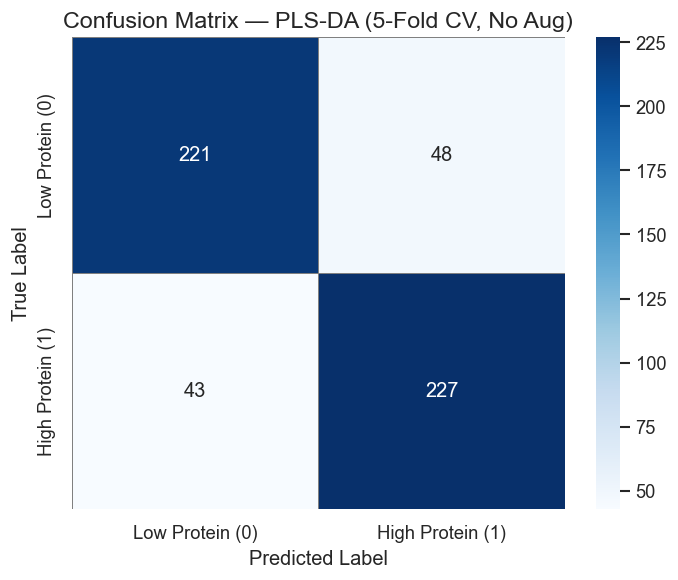

In [5]:
mean_acc  = np.mean([m['accuracy']  for m in plsda_fold_metrics])
std_acc   = np.std( [m['accuracy']  for m in plsda_fold_metrics])
mean_prec = np.mean([m['precision'] for m in plsda_fold_metrics])
std_prec  = np.std( [m['precision'] for m in plsda_fold_metrics])
mean_rec  = np.mean([m['recall']    for m in plsda_fold_metrics])
std_rec   = np.std( [m['recall']    for m in plsda_fold_metrics])
mean_f1   = np.mean([m['f1']        for m in plsda_fold_metrics])
std_f1    = np.std( [m['f1']        for m in plsda_fold_metrics])

print('============================================')
print('  PLS-DA 5-Fold CV Results (No Augmentation)')
print('============================================')
print(f'  Accuracy  : {mean_acc:.4f} +/- {std_acc:.4f}')
print(f'  Precision : {mean_prec:.4f} +/- {std_prec:.4f}')
print(f'  Recall    : {mean_rec:.4f} +/- {std_rec:.4f}')
print(f'  F1-Score  : {mean_f1:.4f} +/- {std_f1:.4f}')
print('============================================')

y_true_all_plsda = np.concatenate(plsda_all_y_true)
y_pred_all_plsda = np.concatenate(plsda_all_y_pred)
plot_confusion_matrix(y_true_all_plsda, y_pred_all_plsda, model_name='PLS-DA (5-Fold CV, No Aug)')

### 4c — Save Best PLS-DA Model

In [6]:
os.makedirs('../../saved_models/revised_no_augmentation', exist_ok=True)

plsda_bundle = {
    'model': plsda_best_model,
    'scaler': None,
    'model_type': 'PLS-DA'
}
joblib.dump(plsda_bundle, '../../saved_models/revised_no_augmentation/pls_da_best.pkl')
print('PLS-DA bundle saved to: saved_models/revised_no_augmentation/pls_da_best.pkl')
print(f'Best fold F1-score: {plsda_best_f1:.4f}')

PLS-DA bundle saved to: saved_models/revised_no_augmentation/pls_da_best.pkl
Best fold F1-score: 0.8727


---
## Section 5 — SVM 5-Fold Cross Validation (No Augmentation)

**Support Vector Machine (SVM)** with an RBF kernel is trained directly on the raw 64 training samples per fold. `StandardScaler` is fitted on the raw training fold only, and `GridSearchCV` with inner 5-fold CV optimises `C` and `gamma`.

### 5a — SVM CV Loop

In [7]:
# -- Accumulators -------------------------------------------------------------
svm_fold_metrics  = []
svm_best_model    = None
svm_best_scaler   = None
svm_best_f1       = 0.0
svm_all_y_true    = []
svm_all_y_pred    = []

param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf'],
}

# -- Outer 5-Fold Loop --------------------------------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    # 1. Split
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    # 2. Scale -- fit on raw training data only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_test_scaled  = scaler.transform(X_test_fold)

    # 3. Inner GridSearchCV (5-fold) on scaled training data
    grid = GridSearchCV(
        SVC(random_state=random_state),
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
    )
    grid.fit(X_train_scaled, y_train_fold)

    # 4. Retrain best SVM on the full scaled training fold
    svm = SVC(**grid.best_params_, random_state=random_state)
    svm.fit(X_train_scaled, y_train_fold)

    # 5. Predict on scaled test fold
    y_pred = svm.predict(X_test_scaled)

    # 6. Compute metrics
    acc  = accuracy_score(y_test_fold, y_pred)
    prec = precision_score(y_test_fold, y_pred, zero_division=0)
    rec  = recall_score(y_test_fold, y_pred, zero_division=0)
    f1   = f1_score(y_test_fold, y_pred, zero_division=0)

    print(
        f'Fold {fold+1}: '
        f'Accuracy={acc:.4f}  Precision={prec:.4f}  '
        f'Recall={rec:.4f}  F1={f1:.4f}  '
        f'Best params={grid.best_params_}'
    )

    svm_fold_metrics.append({'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    svm_all_y_true.append(y_test_fold)
    svm_all_y_pred.append(y_pred)

    if f1 > svm_best_f1:
        svm_best_f1     = f1
        svm_best_model  = svm
        svm_best_scaler = scaler

print(f'\nBest SVM fold F1 : {svm_best_f1:.4f}')

Fold 1: Accuracy=0.7685  Precision=0.7544  Recall=0.7963  F1=0.7748  Best params={'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Fold 2: Accuracy=0.7870  Precision=0.7719  Recall=0.8148  F1=0.7928  Best params={'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
Fold 3: Accuracy=0.7500  Precision=0.7547  Recall=0.7407  F1=0.7477  Best params={'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 4: Accuracy=0.7870  Precision=0.7627  Recall=0.8333  F1=0.7965  Best params={'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Fold 5: Accuracy=0.7290  Precision=0.7119  Recall=0.7778  F1=0.7434  Best params={'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}

Best SVM fold F1 : 0.7965


### 5b — SVM Results Summary

   SVM 5-Fold CV Results (No Augmentation) 
  Accuracy  : 0.7643 +/- 0.0224
  Precision : 0.7511 +/- 0.0206
  Recall    : 0.7926 +/- 0.0319
  F1-Score  : 0.7710 +/- 0.0221


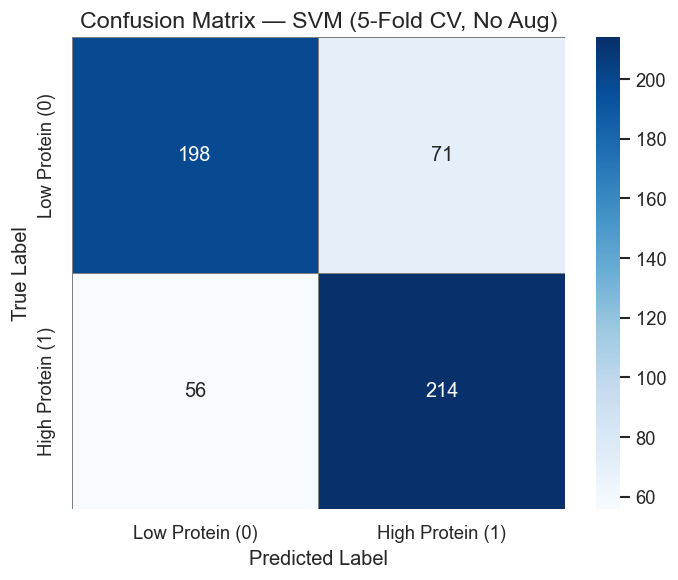

In [8]:
svm_mean_acc  = np.mean([m['accuracy']  for m in svm_fold_metrics])
svm_std_acc   = np.std( [m['accuracy']  for m in svm_fold_metrics])
svm_mean_prec = np.mean([m['precision'] for m in svm_fold_metrics])
svm_std_prec  = np.std( [m['precision'] for m in svm_fold_metrics])
svm_mean_rec  = np.mean([m['recall']    for m in svm_fold_metrics])
svm_std_rec   = np.std( [m['recall']    for m in svm_fold_metrics])
svm_mean_f1   = np.mean([m['f1']        for m in svm_fold_metrics])
svm_std_f1    = np.std( [m['f1']        for m in svm_fold_metrics])

print('============================================')
print('   SVM 5-Fold CV Results (No Augmentation) ')
print('============================================')
print(f'  Accuracy  : {svm_mean_acc:.4f} +/- {svm_std_acc:.4f}')
print(f'  Precision : {svm_mean_prec:.4f} +/- {svm_std_prec:.4f}')
print(f'  Recall    : {svm_mean_rec:.4f} +/- {svm_std_rec:.4f}')
print(f'  F1-Score  : {svm_mean_f1:.4f} +/- {svm_std_f1:.4f}')
print('============================================')

y_true_all_svm = np.concatenate(svm_all_y_true)
y_pred_all_svm = np.concatenate(svm_all_y_pred)
plot_confusion_matrix(y_true_all_svm, y_pred_all_svm, model_name='SVM (5-Fold CV, No Aug)')

### 5c — Save Best SVM Model

In [9]:
svm_bundle = {
    'model': svm_best_model,
    'scaler': svm_best_scaler,
    'model_type': 'SVM'
}
joblib.dump(svm_bundle, '../../saved_models/revised_no_augmentation/svm_best.pkl')
print('SVM bundle saved to: saved_models/revised_no_augmentation/svm_best.pkl')
print(f'Best fold F1-score: {svm_best_f1:.4f}')

SVM bundle saved to: saved_models/revised_no_augmentation/svm_best.pkl
Best fold F1-score: 0.7965


---
## Section 6 — Compare PLS-DA vs SVM

,Accuracy,Accuracy Std,Precision,Precision Std,Recall,Recall Std,F1-Score,F1 Std
Model,,,,,,,,
PLS-DA,0.8312,0.0222,0.8261,0.0241,0.8407,0.0381,0.8328,0.0234
SVM,0.7643,0.0224,0.7511,0.0206,0.7926,0.0319,0.7710,0.0221


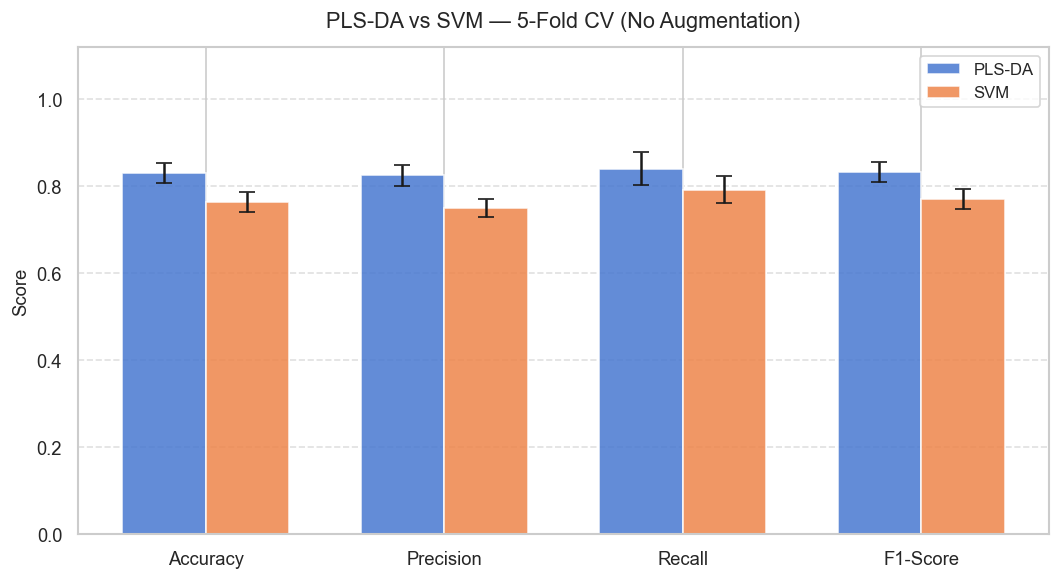

  PLS-DA mean F1 : 0.8328 +/- 0.0234
  SVM    mean F1 : 0.7710 +/- 0.0221
  Better model   : PLS-DA (delta F1 = 0.0618)


In [10]:
comparison_df = pd.DataFrame([
    {
        'Model': 'PLS-DA',
        'Accuracy': mean_acc,   'Accuracy Std': std_acc,
        'Precision': mean_prec, 'Precision Std': std_prec,
        'Recall': mean_rec,     'Recall Std': std_rec,
        'F1-Score': mean_f1,    'F1 Std': std_f1,
    },
    {
        'Model': 'SVM',
        'Accuracy': svm_mean_acc,   'Accuracy Std': svm_std_acc,
        'Precision': svm_mean_prec, 'Precision Std': svm_std_prec,
        'Recall': svm_mean_rec,     'Recall Std': svm_std_rec,
        'F1-Score': svm_mean_f1,    'F1 Std': svm_std_f1,
    },
])
display(comparison_df.set_index('Model').round(4))

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
plsda_means  = [mean_acc,     mean_prec,     mean_rec,     mean_f1]
plsda_stds   = [std_acc,      std_prec,      std_rec,      std_f1]
svm_means    = [svm_mean_acc, svm_mean_prec, svm_mean_rec, svm_mean_f1]
svm_stds     = [svm_std_acc,  svm_std_prec,  svm_std_rec,  svm_std_f1]

x      = np.arange(len(metric_names))
width  = 0.35
colors = sns.color_palette('muted', 2)

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, plsda_means, width, yerr=plsda_stds, capsize=5,
               label='PLS-DA', color=colors[0], alpha=0.85)
bars2 = ax.bar(x + width/2, svm_means,   width, yerr=svm_stds,   capsize=5,
               label='SVM',    color=colors[1], alpha=0.85)

ax.set_title('PLS-DA vs SVM — 5-Fold CV (No Augmentation)', fontsize=13, pad=12)
ax.set_ylabel('Score', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

better_model = 'SVM' if svm_mean_f1 >= mean_f1 else 'PLS-DA'
margin       = abs(svm_mean_f1 - mean_f1)
print('============================================')
print(f'  PLS-DA mean F1 : {mean_f1:.4f} +/- {std_f1:.4f}')
print(f'  SVM    mean F1 : {svm_mean_f1:.4f} +/- {svm_std_f1:.4f}')
print(f'  Better model   : {better_model} (delta F1 = {margin:.4f})')
print('============================================')

---
## Section 7 — Save Per-Fold Metrics to Disk

Results are saved to `data/results/no_aug/` so that notebook 07 can load them without retraining.

In [11]:
import json

os.makedirs('../../data/results/no_aug', exist_ok=True)

plsda_results = {
    'model': 'PLS-DA',
    'fold_metrics': plsda_fold_metrics,
    'mean_accuracy':  float(np.mean([m['accuracy']  for m in plsda_fold_metrics])),
    'std_accuracy':   float(np.std( [m['accuracy']  for m in plsda_fold_metrics])),
    'mean_precision': float(np.mean([m['precision'] for m in plsda_fold_metrics])),
    'std_precision':  float(np.std( [m['precision'] for m in plsda_fold_metrics])),
    'mean_recall':    float(np.mean([m['recall']    for m in plsda_fold_metrics])),
    'std_recall':     float(np.std( [m['recall']    for m in plsda_fold_metrics])),
    'mean_f1':        float(np.mean([m['f1']        for m in plsda_fold_metrics])),
    'std_f1':         float(np.std( [m['f1']        for m in plsda_fold_metrics])),
    'all_y_true':     [int(v) for v in np.concatenate(plsda_all_y_true)],
    'all_y_pred':     [int(v) for v in np.concatenate(plsda_all_y_pred)],
}
with open('../../data/results/no_aug/plsda_results.json', 'w') as f:
    json.dump(plsda_results, f, indent=2)
print('PLS-DA results saved to: data/results/no_aug/plsda_results.json')

svm_results = {
    'model': 'SVM',
    'fold_metrics': svm_fold_metrics,
    'mean_accuracy':  float(np.mean([m['accuracy']  for m in svm_fold_metrics])),
    'std_accuracy':   float(np.std( [m['accuracy']  for m in svm_fold_metrics])),
    'mean_precision': float(np.mean([m['precision'] for m in svm_fold_metrics])),
    'std_precision':  float(np.std( [m['precision'] for m in svm_fold_metrics])),
    'mean_recall':    float(np.mean([m['recall']    for m in svm_fold_metrics])),
    'std_recall':     float(np.std( [m['recall']    for m in svm_fold_metrics])),
    'mean_f1':        float(np.mean([m['f1']        for m in svm_fold_metrics])),
    'std_f1':         float(np.std( [m['f1']        for m in svm_fold_metrics])),
    'all_y_true':     [int(v) for v in np.concatenate(svm_all_y_true)],
    'all_y_pred':     [int(v) for v in np.concatenate(svm_all_y_pred)],
}
with open('../../data/results/no_aug/svm_results.json', 'w') as f:
    json.dump(svm_results, f, indent=2)
print('SVM results saved to: data/results/no_aug/svm_results.json')

PLS-DA results saved to: data/results/no_aug/plsda_results.json
SVM results saved to: data/results/no_aug/svm_results.json
